# Homework 7: Predicting Housing Prices - Build Your Own Model

## Due Date: 11:59pm Thursday, March 25th

## You are not required to complete this notebook nor will you be graded on this part -- this only serves as a guide to simplify the process of submitting your model predictions for the contest. 

In [1]:
# Some Imports You Might Need
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

import zipfile
import os

from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model as lm

# Plot settings
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.size"] = 12

# Extract Dataset
with zipfile.ZipFile("cook_county_contest_data.zip") as item:
    item.extractall()

### Note

This notebook is specifically designed to guide you through the process of exporting your model's predictions on the test dataset for submission so you can see how your model stacks up against others'. 

Most of what you have done in question 8 of Homework 7 should be transferrable here. However, there are a few small changes you will need to make on your part to make sure the function meets our requirements, so **please read the following instructions very carefully**:

## Step 1. Set up all the helper functions for your `process_data_fm` function.

**Copy-paste all of the helper functions your `process_data_fm` need here in the following cell**. Note that we have provided you with the skeletons for some of the feature engineering functions we asked you to implement in the assignment below, but feel free to also add more of your own functions. You **do not** have to fill out all of the functions in the cell below -- only fill out those that are actually useful to your feature engineering pipeline.

In [2]:
def add_total_bedrooms(data):
    """
    Input:
      data (data frame): a data frame containing at least the Description column.
    """
    with_rooms = data.copy()
    with_rooms["Bedrooms"] = (
        with_rooms["Description"]
        .str.extract(r"(\d+) of which are bedrooms")
        .astype(int)
    )
    return with_rooms


def add_total_bathrooms(data):
    """
    Input:
      data (data frame): a data frame containing at least the Description column.
    """
    with_rooms = data.copy()
    with_rooms["Bathrooms"] = (
        with_rooms["Description"]
        .str.extract(r"(\d+) of which are bathrooms")
        .astype(int)
    )
    return with_rooms


def ohe_roof_material(data):
    """
    One-hot-encodes roof material.  New columns are of the form 0x_QUALITY.
    """
    oh_enc = OneHotEncoder()
    oh_enc.fit(data[["Roof Material"]])
    dummies = pd.DataFrame(
        oh_enc.transform(data[["Roof Material"]]).todense(),
        columns=oh_enc.get_feature_names(),
        index=data.index,
    )
    return data.join(dummies)


def remove_outliers(data, variable, lower=-np.inf, upper=np.inf):
    """
    Input:
      data (data frame): the table to be filtered
      variable (string): the column with numerical outliers
      lower (numeric): observations with values lower than this will be removed
      upper (numeric): observations with values higher than this will be removed

    Output:
      a winsorized data frame with outliers removed

    Note: This function should not change mutate the contents of data.
    """
    return data.loc[(data[variable] >= lower) & (data[variable] <= upper)]


def process_data_gm(data, pipeline_functions, prediction_col):
    """Process the data for a guided model."""
    for function, arguments, keyword_arguments in pipeline_functions:
        if keyword_arguments and (not arguments):
            data = data.pipe(function, **keyword_arguments)
        elif (not keyword_arguments) and (arguments):
            data = data.pipe(function, *arguments)
        else:
            data = data.pipe(function)
    X = data.drop(columns=[prediction_col]).to_numpy()
    y = data.loc[:, prediction_col].to_numpy()
    return X, y


def select_columns(data, *columns):
    """Select only columns passed as arguments."""
    return data.loc[:, columns]

## Step 2. Setup your `process_data_fm` function

**Copy-paste your implementation of `process_data_fm` from question 8 of Homework 7 into the following cell.**

Here are a few additional things **you should check and change to make sure your `process_data_fm` function satisfies**:
- Unlike the homework, we will not be expecting your `process_data_fm` function to return both the design matrix `X` and the observed target vector `y`; your function should now **only return X**.
- In addition, you **may NOT incorporate the `Sale Price` column in your feature engineering process** (so things such as removing outliers in Sale Price that would work for question 8 will no longer apply here anymore)
- We understand that the original training and test data have a lot illegitimate prices that actually detract quite a bit from your model's performance. In order to help you focus on actually **engineering the best features and looking for patterns within your data**, we have prefiltered the data a bit more and removed those outliers in advance.

In [3]:
# Please include all of your feature engineering process inside this function.
# Do not modify the parameters of the function below.
# Note that data will no longer have the column Sale Price in it directly, so plan your feature engineering process around that.
def process_data_fm(data):
    # Replace the following line with your own feature engineering pipeline
    data = add_total_bedrooms(data)
    data = add_total_bathrooms(data)

    data["Estimate (Land)"] = (
        data["Estimate (Land)"]
        .apply(np.log)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    data["Estimate (Building)"] = (
        data["Estimate (Building)"]
        .apply(np.log)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    data["Building Square Feet"] = (
        data["Building Square Feet"]
        .apply(np.log)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    data["Land Square Feet"] = (
        data["Land Square Feet"]
        .apply(np.log)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    data["Use"] = data["Use"].apply(np.log).replace([np.inf, -np.inf], np.nan).fillna(0)
    data["Pure Market Filter"] = (
        data["Pure Market Filter"]
        .apply(np.log)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )
    data["Age"] = data["Age"].apply(np.sqrt)
    data["Total Rooms"] = data["Bathrooms"] + data["Bedrooms"]
    data["Total Rooms"] = data["Total Rooms"] ** 2
    data["Bedrooms"] = data["Bedrooms"] ** 2
    data["Bathrooms"] = data["Bathrooms"] ** 2

    data = select_columns(
        data,
        "Estimate (Land)",
        "Estimate (Building)",
        "Building Square Feet",
        "Land Square Feet",
        "Age",
        "Bedrooms",
        "Bathrooms",
    )

    X = data
    return X

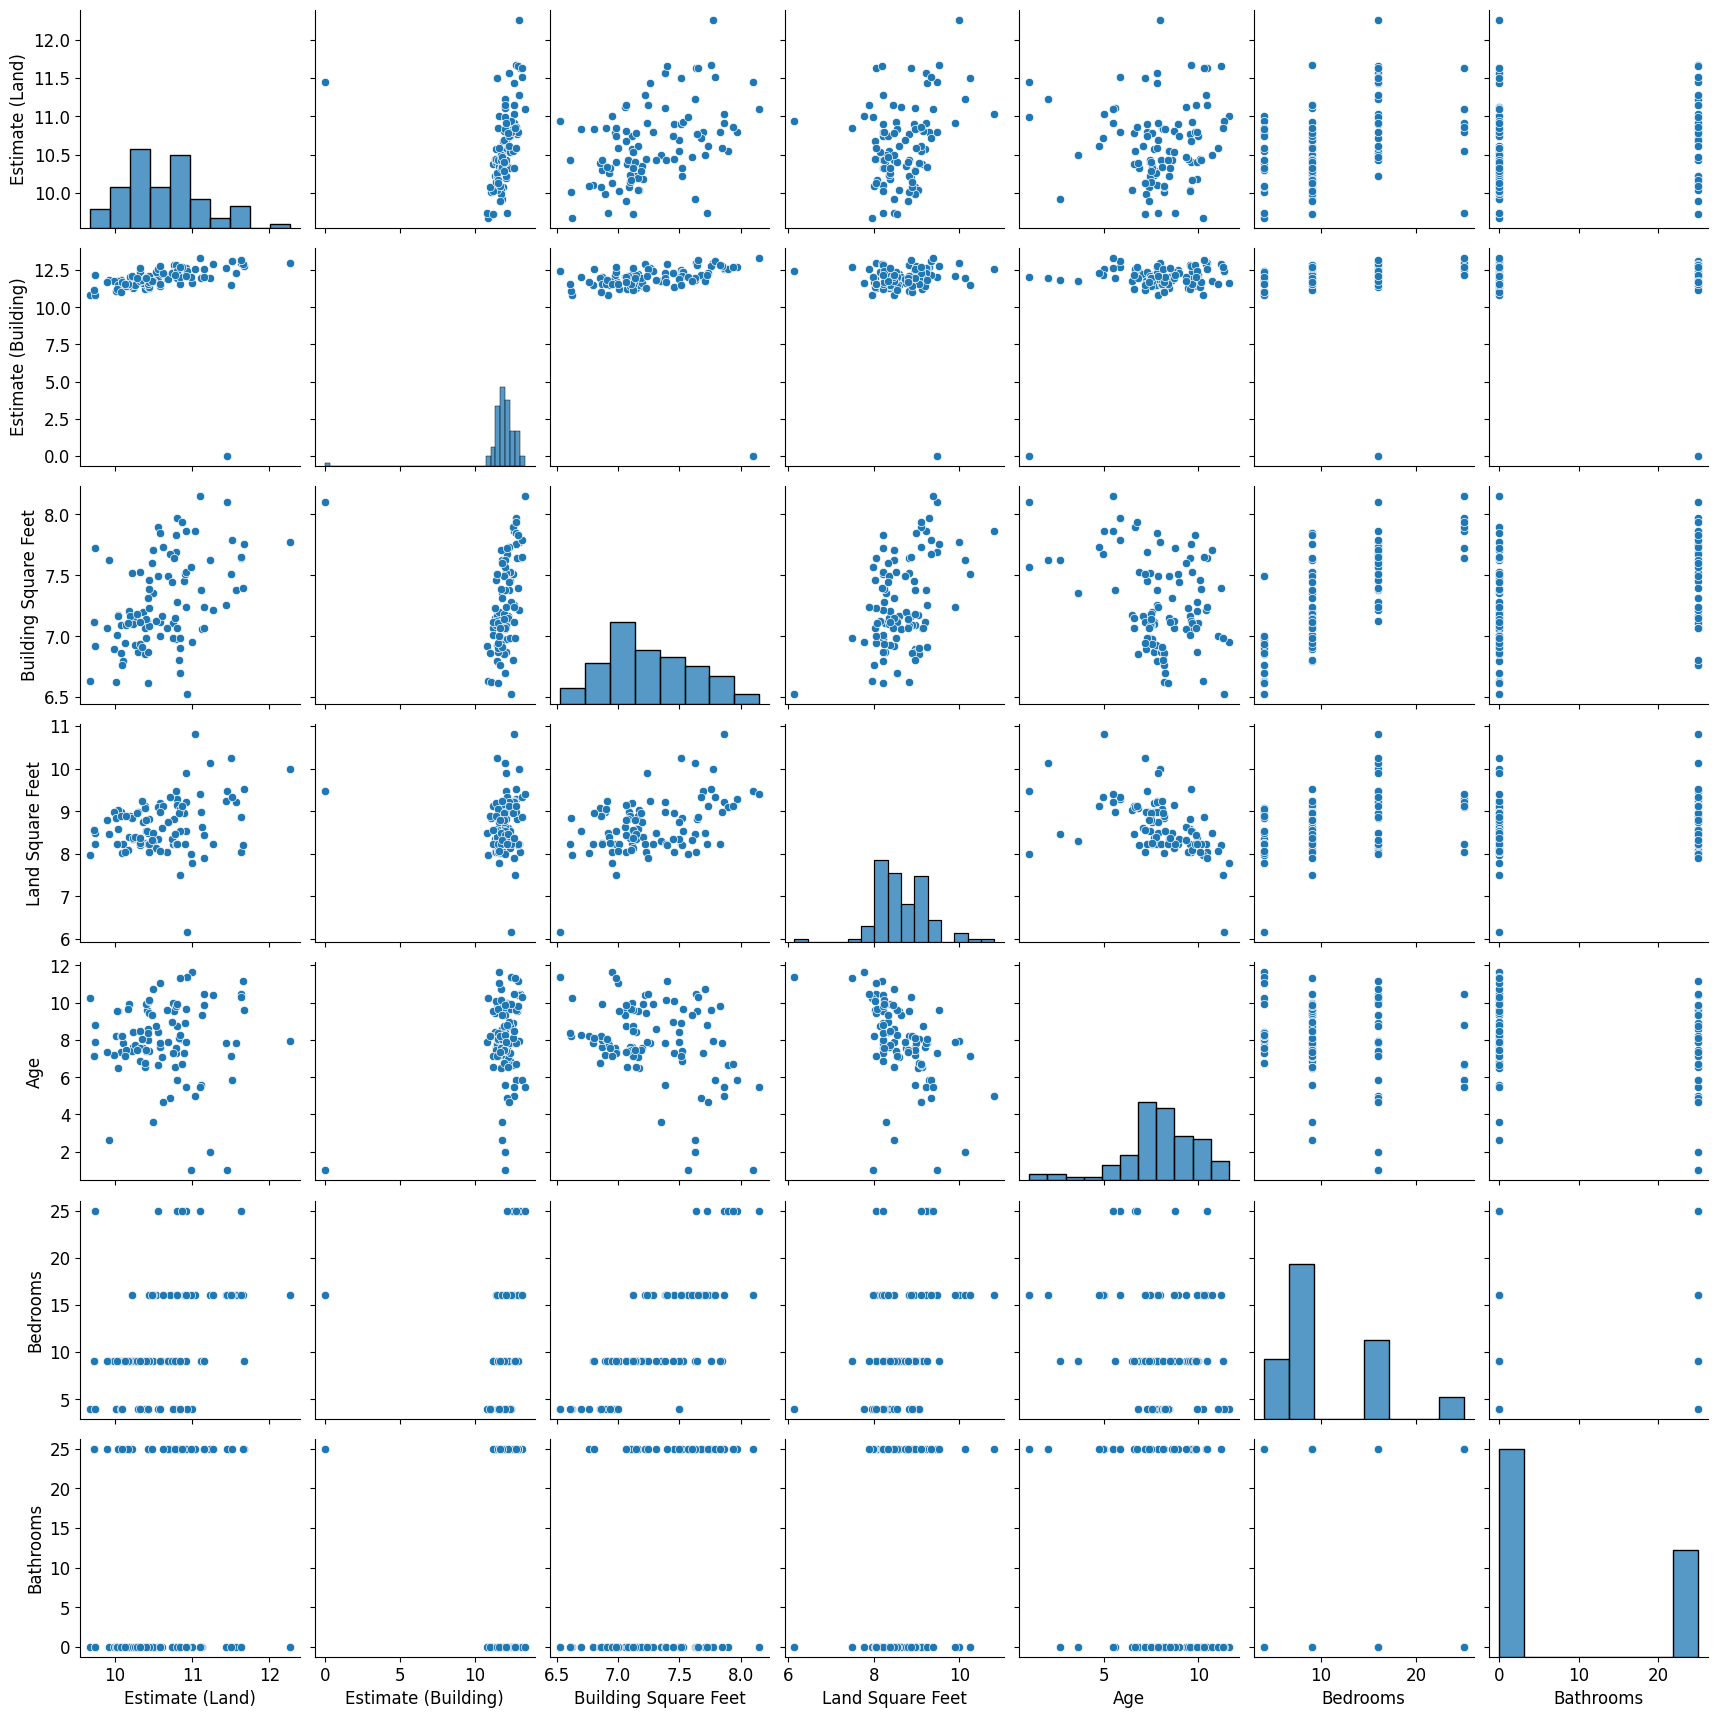

In [4]:
train_data = pd.read_csv("cook_county_contest_train.csv", index_col="Unnamed: 0")
train_data = train_data.drop(columns=["Sale Price"])
X_train = process_data_fm(train_data)
sns.pairplot(X_train.sample(100))

<AxesSubplot:>

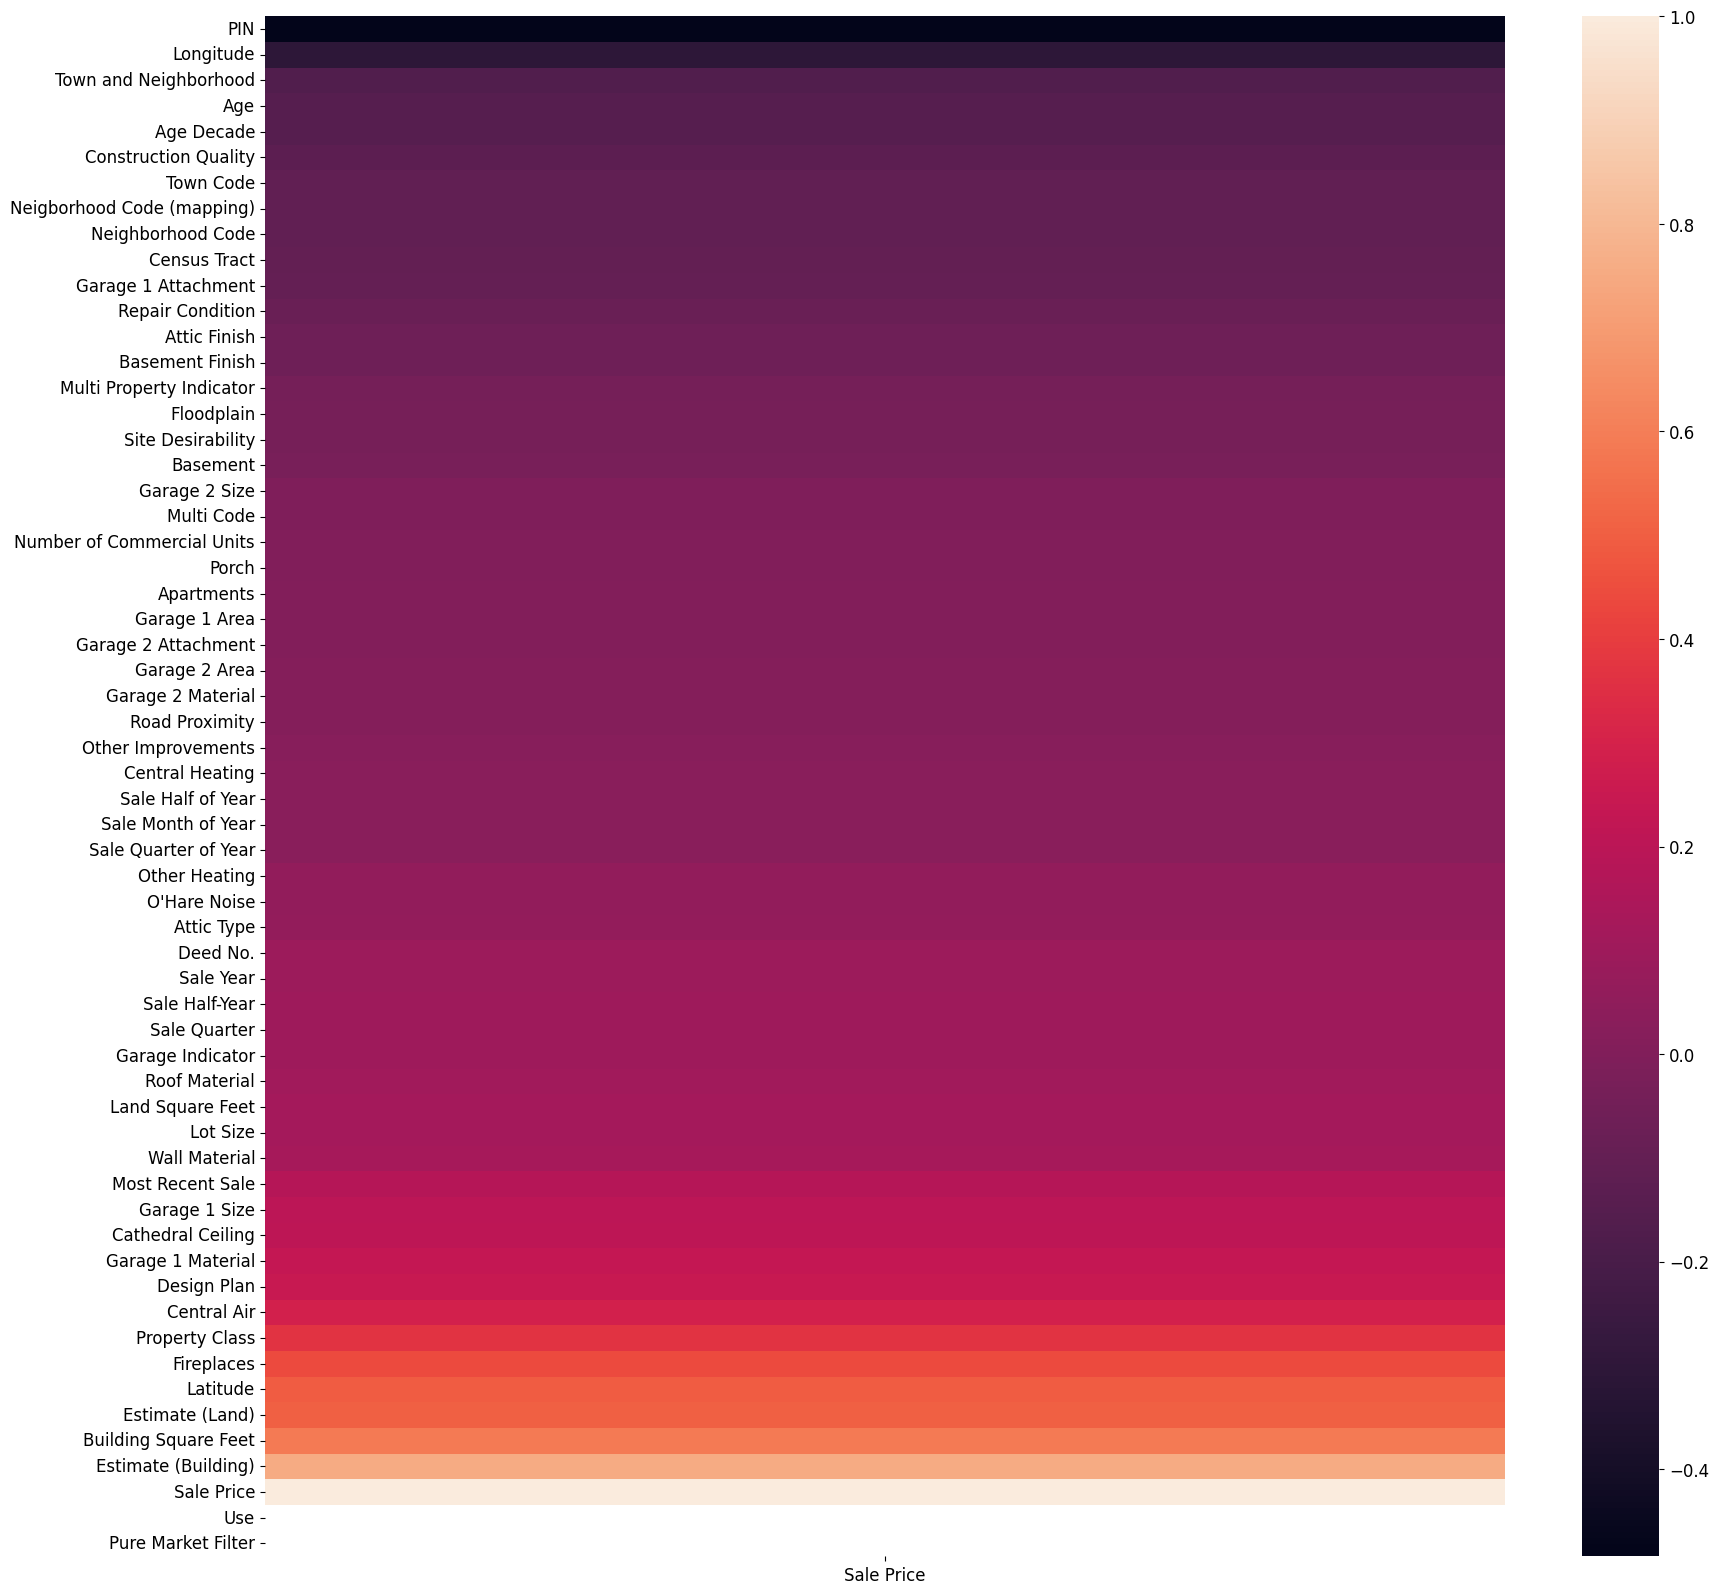

In [5]:
plt.figure(figsize=(20, 20))
corr_matrix = pd.read_csv(
    "cook_county_contest_train.csv", index_col="Unnamed: 0"
).corr()
sns.heatmap(corr_matrix[["Sale Price"]].sort_values("Sale Price"))

## Step 3. Train your model

Run the following cell to import the new set of training data to fit your model on. **No coding is required from you for this part**. If your `process_data_fm` satisfies all the specified requirements, the cell should run without any error.

**As usual**, your model will predict the log-transformed sale price, and our autograder will handle transforming your predictions back to the normal vlaues.

In [6]:
train_data = pd.read_csv("cook_county_contest_train.csv", index_col="Unnamed: 0")
y_train = np.log(train_data["Sale Price"])
train_data = train_data.drop(columns=["Sale Price"])
X_train = process_data_fm(train_data)
model = lm.LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)
print(model.score(X_train, y_train))

0.48645054035788526


In [7]:
def rmse(predicted, actual):
    """
    Calculates RMSE from actual and predicted values
    Input:
      predicted (1D array): vector of predicted/fitted values
      actual (1D array): vector of actual values
    Output:
      a float, the root-mean square error
    """
    return np.sqrt(np.mean((actual - predicted) ** 2))


def delog(x):
    return np.exp(x)


print(rmse(delog(model.predict(X_train)), delog(y_train)))

127791.84105233161


In [8]:
127791.84105232974

127791.84105232974

In [9]:
196323.81108033628

196323.81108033628

## Step 4. Make Predictions on the Test Dataset

Run the following cell to estimate the sale price on the test dataset and export your model's predictions as a csv file called `predictions.csv`. Download the csv file from the same directory as the current notebook and submit it to the Gradescope assignment **Homework 7 - Build Your Own Model** and you should be able to see your model's rank from there!

In [10]:
test_data = pd.read_csv("cook_county_contest_test.csv", index_col="Unnamed: 0")
X_test = process_data_fm(test_data)
y_test_predicted = model.predict(X_test)
predictions = pd.DataFrame({"Sale Price": y_test_predicted})
predictions.to_csv("predictions.csv")
print(
    "Your predictions have been exported as predictions.csv. Please download the file and submit it to Gradescope. "
)

Your predictions have been exported as predictions.csv. Please download the file and submit it to Gradescope. 
